In [1]:
import os
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("results", exist_ok=True)
print("Folders 'checkpoints' and 'results' were created")

Ordner 'checkpoints' und 'results' wurden erstellt!


In [2]:
%%writefile ddpm.py
import torch
import torch.nn as nn
import torch.nn.functional as F

class LinearNoiseScheduler:
    def __init__(self, timesteps: int = 1000, beta_start: float = 1e-4, beta_end: float = 0.02):
        self.timesteps = timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end

        self.betas = torch.linspace(beta_start, beta_end, timesteps)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )

    def sample_forward(self, x_0: torch.Tensor, t: torch.Tensor, device: str):
        noise = torch.randn_like(x_0).to(device)
        sqrt_alpha_bar = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1).to(device)
        sqrt_one_minus_alpha_bar = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1).to(device)
        x_t = sqrt_alpha_bar * x_0 + sqrt_one_minus_alpha_bar * noise
        return x_t, noise


class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, time: torch.Tensor) -> torch.Tensor:
        device = time.device
        half_dim = self.dim // 2
        embeddings = torch.log(torch.tensor(10000.0, device=device)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, time_emb_dim: int):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.GELU(),
            nn.Linear(time_emb_dim, out_channels)
        )
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.gn1 = nn.GroupNorm(8, out_channels)
        self.gn2 = nn.GroupNorm(8, out_channels)
        self.act = nn.GELU()

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.act(self.gn1(self.conv1(x)))
        time_emb = self.time_mlp(t_emb)[:, :, None, None]
        h = h + time_emb
        h = self.act(self.gn2(self.conv2(h)))
        return h + self.shortcut(x)


class UNet(nn.Module):
    def __init__(self, in_channels: int = 1, base_channels: int = 32, time_emb_dim: int = 128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(base_channels),
            nn.Linear(base_channels, time_emb_dim),
            nn.GELU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        self.inc = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)
        self.down1 = ResidualBlock(base_channels, base_channels * 2, time_emb_dim)
        self.down2 = ResidualBlock(base_channels * 2, base_channels * 4, time_emb_dim)

        self.pool = nn.MaxPool2d(2)

        self.bot1 = ResidualBlock(base_channels * 4, base_channels * 4, time_emb_dim)
        self.bot2 = ResidualBlock(base_channels * 4, base_channels * 4, time_emb_dim)

        self.up1 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.res_up1 = ResidualBlock(base_channels * 6, base_channels * 2, time_emb_dim)

        self.up2 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.res_up2 = ResidualBlock(base_channels * 3, base_channels, time_emb_dim)

        self.outc = nn.Conv2d(base_channels, in_channels, kernel_size=1)

    def forward(self, x: torch.Tensor, timestep: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(timestep)

        x1 = self.inc(x)
        x1_res = self.down1(x1, t_emb)

        x2_pooled = self.pool(x1_res)
        x2_res = self.down2(x2_pooled, t_emb)

        x3_pooled = self.pool(x2_res)

        x_bot = self.bot1(x3_pooled, t_emb)
        x_bot = self.bot2(x_bot, t_emb)

        x_up1 = self.up1(x_bot)
        x_up1 = torch.cat([x_up1, x2_res], dim=1)
        x_up1 = self.res_up1(x_up1, t_emb)

        x_up2 = self.up2(x_up1)
        x_up2 = torch.cat([x_up2, x1_res], dim=1)
        x_up2 = self.res_up2(x_up2, t_emb)

        return self.outc(x_up2)

Writing ddpm.py


In [5]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from ddpm import UNet, LinearNoiseScheduler

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Ensure target directory exists for checkpoint saving
os.makedirs("checkpoints", exist_ok=True)

epochs = 15
batch_size = 128
lr = 2e-4
timesteps = 1000

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t: (t * 2) - 1)
])

dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

scheduler = LinearNoiseScheduler(timesteps=timesteps)

# If LinearNoiseScheduler is an nn.Module, send it to device
if isinstance(scheduler, nn.Module):
    scheduler.to(device)

model = UNet(in_channels=1, base_channels=32).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
criterion = nn.MSELoss()

model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for step, (images, _) in enumerate(dataloader):
        images = images.to(device)
        optimizer.zero_grad()

        # Pass t on the appropriate device matching scheduler tensors
        t = torch.randint(0, timesteps, (batch_size,), device=device).long()

        # Pass t.cpu() because scheduler internal buffers are on CPU
        x_noisy, noise = scheduler.sample_forward(images, t.cpu(), device)
        predicted_noise = model(x_noisy, t)

        loss = criterion(predicted_noise, noise)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.5f}")

torch.save(model.state_dict(), "checkpoints/ddpm_mnist.pt")
print("Training done! Modell saved to 'checkpoints/ddpm_mnist.pt'.")

Using device: cuda
Epoch [1/15] - Loss: 0.07239
Epoch [2/15] - Loss: 0.03440
Epoch [3/15] - Loss: 0.03049
Epoch [4/15] - Loss: 0.02865
Epoch [5/15] - Loss: 0.02746
Epoch [6/15] - Loss: 0.02673
Epoch [7/15] - Loss: 0.02620
Epoch [8/15] - Loss: 0.02528
Epoch [9/15] - Loss: 0.02528
Epoch [10/15] - Loss: 0.02481
Epoch [11/15] - Loss: 0.02461
Epoch [12/15] - Loss: 0.02479
Epoch [13/15] - Loss: 0.02419
Epoch [14/15] - Loss: 0.02393
Epoch [15/15] - Loss: 0.02384
Training abgeschlossen! Modell wurde in 'checkpoints/ddpm_mnist.pt' gespeichert.


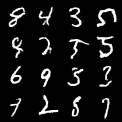

In [9]:
import torch
from torchvision.utils import save_image
from IPython.display import Image, display
from ddpm import UNet, LinearNoiseScheduler

@torch.no_grad()
def sample(model, scheduler, num_samples=16, device="cuda"):
    model.eval()
    img_size = 28
    x = torch.randn(num_samples, 1, img_size, img_size, device=device)

    for t in reversed(range(scheduler.timesteps)):
        t_batch = torch.full((num_samples,), t, device=device, dtype=torch.long)
        predicted_noise = model(x, t_batch)

        alpha = scheduler.alphas[t].to(device)
        alpha_cumprod = scheduler.alphas_cumprod[t].to(device)
        beta = scheduler.betas[t].to(device)

        noise = torch.randn_like(x) if t > 0 else 0

        mean = (1 / torch.sqrt(alpha)) * (
            x - (beta / torch.sqrt(1 - alpha_cumprod)) * predicted_noise
        )
        x = mean + torch.sqrt(beta) * noise

    x = (x.clamp(-1, 1) + 1) / 2
    return x

scheduler = LinearNoiseScheduler()
model = UNet(in_channels=1, base_channels=32).to(device)
model.load_state_dict(torch.load("checkpoints/ddpm_mnist.pt", map_location=device))

samples = sample(model, scheduler, num_samples=16, device=device)
save_image(samples, "results/generated_samples.png", nrow=4)

# Show Image in Notebook
display(Image("results/generated_samples.png"))